# 08 — Personal Calibration Showcase

**Living Model Demo & Funding Pitch**

Consumer wrist wearables report heart rate with a **person-specific bias** that population averages cannot fix. We built a nightly recalibration engine that:

1. Starts from a **population prior** (Bayesian cold-start)
2. Learns each user's **personal offset** over time (tightening confidence intervals)
3. Detects **anomalies** (e.g. firmware shifts)
4. Generalizes to **other body metrics** (HRV demo below)

All numbers in this notebook are computed live from synthetic paired-device data (20 users × 90 nights).


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from hr_selection import config
from hr_selection.personal.anomaly import detect_offset_anomaly
from hr_selection.personal.backtest import (
    STRATEGIES,
    aggregate_backtest_metrics,
    cumulative_mae_curve,
    walk_forward_backtest,
)
from hr_selection.personal.estimator import OffsetState, batch_update_offset, update_offset
from hr_selection.synthetic.calibration import (
    HR_METRIC,
    HRV_METRIC,
    build_paired_nights,
    generate_calibration_data,
)

ROOT = config.ROOT
FIG_DIR = ROOT / "data" / "hr_out" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

WARMUP = 7
HOLDOUT_START = 60
CHECKPOINTS = [30, 60, 90]
SEED = config.SEED

def save_fig(name: str):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved {path}")


## 1. The Problem — Raw Wrist Bias Varies by Person

**Paired nights:** 1,451 | **Raw wrist MAE vs chest:** 6.24 bpm | **Mean offset:** 2.10 bpm

Saved /Users/elopez/Desktop/health-research/health-data-analysis/data/hr_out/figures/offset_distribution.png


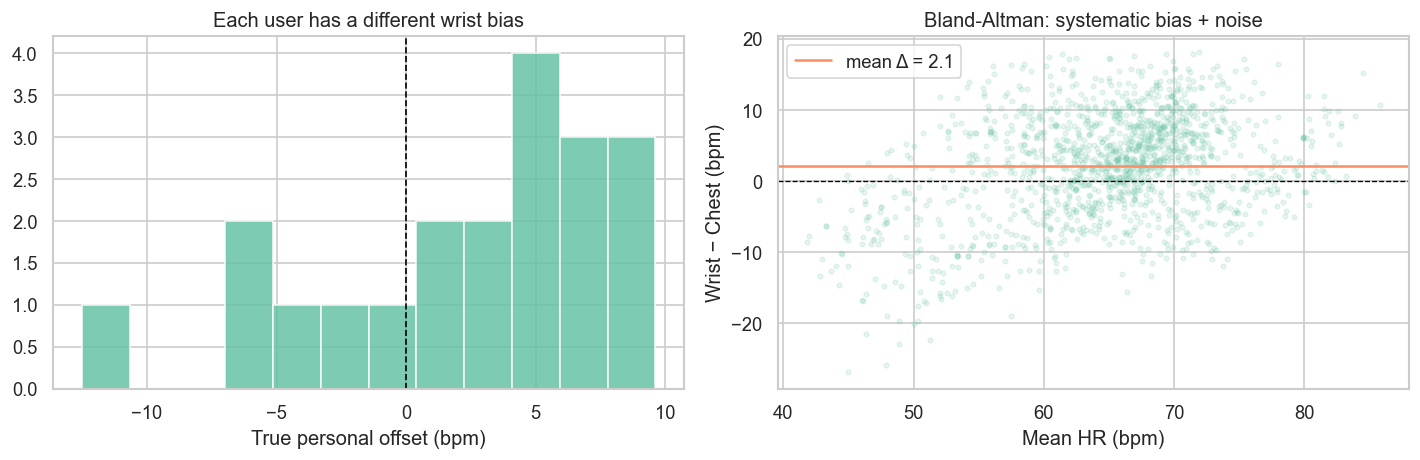

In [2]:
readings_path = ROOT / "data" / "hr_calibration_dataset.csv"
truth_path = ROOT / "data" / "hr_calibration_truth.csv"

if not readings_path.exists():
    from hr_selection.synthetic.calibration import write_calibration_dataset
    write_calibration_dataset(ROOT / "data", seed=SEED)

readings = pd.read_csv(readings_path, parse_dates=["date"])
truth = pd.read_csv(truth_path)
paired = build_paired_nights(readings).sort_values(["user_id", "date"]).reset_index(drop=True)

pop_mean = paired["delta"].mean()
raw_mae = (paired["wrist"] - paired["chest"]).abs().mean()

display(Markdown(f"**Paired nights:** {len(paired):,} | **Raw wrist MAE vs chest:** {raw_mae:.2f} bpm | **Mean offset:** {pop_mean:.2f} bpm"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Per-user true offsets
axes[0].hist(truth["personal_offset"], bins=12, edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="k", ls="--", lw=1)
axes[0].set_xlabel("True personal offset (bpm)")
axes[0].set_title("Each user has a different wrist bias")

# Bland-Altman style
mean_hr = (paired["chest"] + paired["wrist"]) / 2
diff = paired["wrist"] - paired["chest"]
axes[1].scatter(mean_hr, diff, alpha=0.15, s=8)
axes[1].axhline(pop_mean, color="C1", label=f"mean Δ = {pop_mean:.1f}")
axes[1].axhline(0, color="k", ls="--", lw=0.8)
axes[1].set_xlabel("Mean HR (bpm)")
axes[1].set_ylabel("Wrist − Chest (bpm)")
axes[1].set_title("Bland-Altman: systematic bias + noise")
axes[1].legend()

save_fig("offset_distribution.png")
plt.show()


## 2. Population Prior — Cold-Start Baseline Fusion

Saved /Users/elopez/Desktop/health-research/health-data-analysis/data/hr_out/figures/population_prior.png


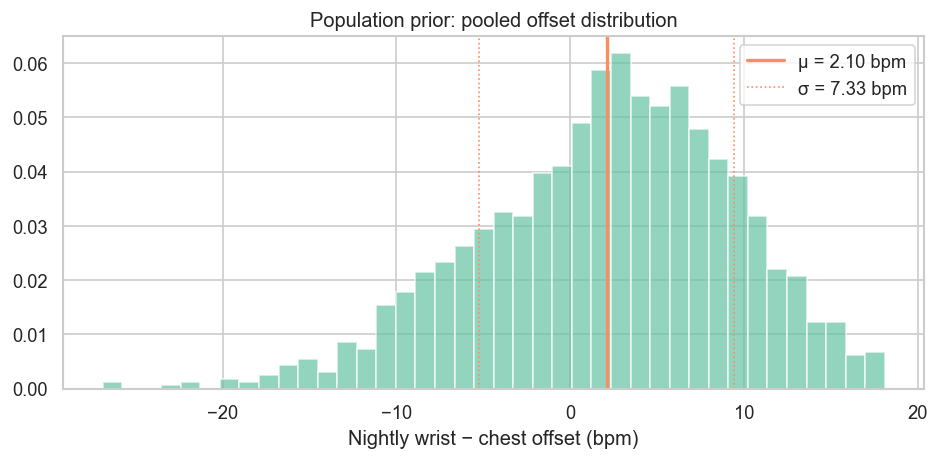

New users start with prior offset **2.10 ± 7.33 bpm**. Correcting everyone by the population mean helps on average but cannot capture individual bias.

In [3]:
pop_std = paired["delta"].std()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(paired["delta"], bins=40, density=True, alpha=0.7, edgecolor="white")
ax.axvline(pop_mean, color="C1", lw=2, label=f"μ = {pop_mean:.2f} bpm")
ax.axvline(pop_mean - pop_std, color="C1", ls=":", lw=1)
ax.axvline(pop_mean + pop_std, color="C1", ls=":", lw=1, label=f"σ = {pop_std:.2f} bpm")
ax.set_xlabel("Nightly wrist − chest offset (bpm)")
ax.set_title("Population prior: pooled offset distribution")
ax.legend()
save_fig("population_prior.png")
plt.show()

display(Markdown(
    f"New users start with prior offset **{pop_mean:.2f} ± {pop_std:.2f} bpm**. "
    "Correcting everyone by the population mean helps on average but cannot capture individual bias."
))


## 3. Personal Convergence — Learning Your Offset Over Time

Saved /Users/elopez/Desktop/health-research/health-data-analysis/data/hr_out/figures/convergence.png


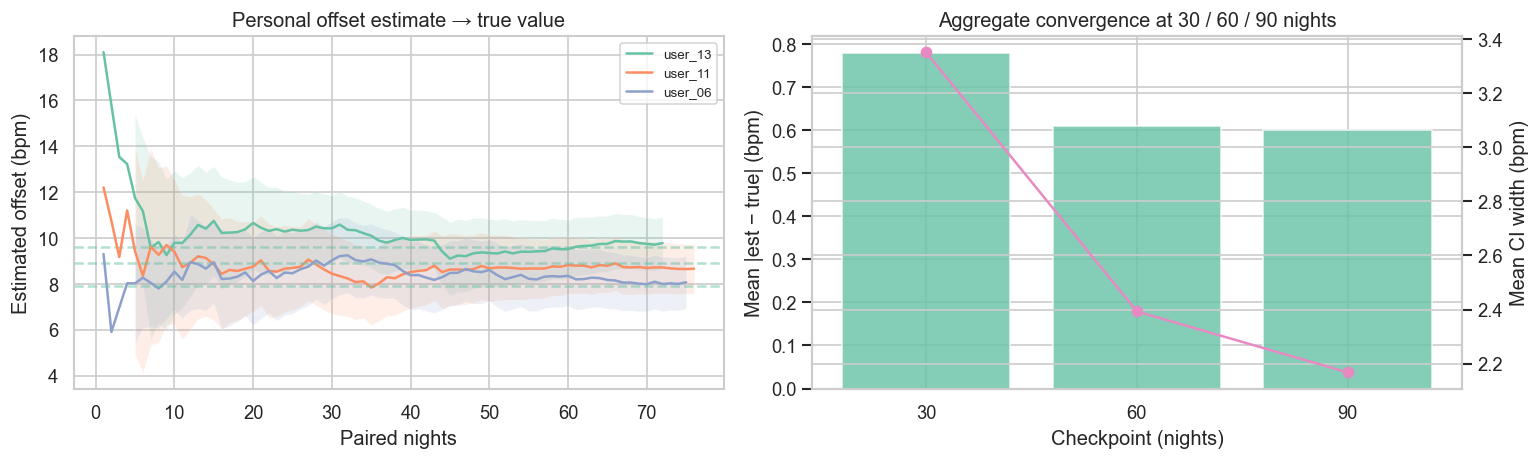

,checkpoint,mean_abs_error,mean_ci_width
0,30,0.779500,3.350421
1,60,0.609500,2.393176
2,90,0.599666,2.167517


In [4]:
def convergence_snapshots(paired, truth, checkpoints):
    truth_map = truth.set_index("user_id")
    rows = []
    for user_id, grp in paired.groupby("user_id"):
        grp = grp.sort_values("date").reset_index(drop=True)
        true_off = float(truth_map.loc[user_id, "personal_offset"])
        state = OffsetState()
        n_pairs = len(grp)
        for i, row in grp.iterrows():
            state = update_offset(state, float(row["delta"]))
            for cp in checkpoints:
                if i + 1 == min(cp, n_pairs):
                    rows.append({
                        "user_id": user_id,
                        "checkpoint": cp,
                        "abs_error": abs(state.offset_mean - true_off),
                        "ci_width": state.ci_high - state.ci_low if state.ci_high == state.ci_high else np.nan,
                        "estimated": state.offset_mean,
                        "true": true_off,
                    })
    return pd.DataFrame(rows)

conv = convergence_snapshots(paired, truth, CHECKPOINTS)
agg = conv.groupby("checkpoint").agg(
    mean_abs_error=("abs_error", "mean"),
    mean_ci_width=("ci_width", "mean"),
).reset_index()

# Sample user trajectories
sample_users = truth.nlargest(3, "personal_offset")["user_id"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for uid in sample_users:
    grp = paired[paired["user_id"] == uid].sort_values("date").reset_index(drop=True)
    true_off = float(truth.loc[truth["user_id"] == uid, "personal_offset"].iloc[0])
    state = OffsetState()
    nights, ests, lo, hi = [], [], [], []
    for i, row in grp.iterrows():
        state = update_offset(state, float(row["delta"]))
        nights.append(i + 1)
        ests.append(state.offset_mean)
        lo.append(state.ci_low if state.ci_low == state.ci_low else np.nan)
        hi.append(state.ci_high if state.ci_high == state.ci_high else np.nan)
    axes[0].plot(nights, ests, label=uid)
    axes[0].fill_between(nights, lo, hi, alpha=0.15)
    axes[0].axhline(true_off, ls="--", alpha=0.5)

axes[0].set_xlabel("Paired nights")
axes[0].set_ylabel("Estimated offset (bpm)")
axes[0].set_title("Personal offset estimate → true value")
axes[0].legend(fontsize=8)

axes[1].bar(agg["checkpoint"].astype(str), agg["mean_abs_error"], alpha=0.8, label="|est − true|")
ax2 = axes[1].twinx()
ax2.plot(agg["checkpoint"].astype(str), agg["mean_ci_width"], "o-", color="C3", label="CI width")
axes[1].set_xlabel("Checkpoint (nights)")
axes[1].set_ylabel("Mean |est − true| (bpm)")
ax2.set_ylabel("Mean CI width (bpm)")
axes[1].set_title("Aggregate convergence at 30 / 60 / 90 nights")

save_fig("convergence.png")
plt.show()

display(agg)


## 4. Walk-Forward Backtest — Out-of-Sample Proof (Finance Style)

Saved /Users/elopez/Desktop/health-research/health-data-analysis/data/hr_out/figures/backtest_oos_mae.png


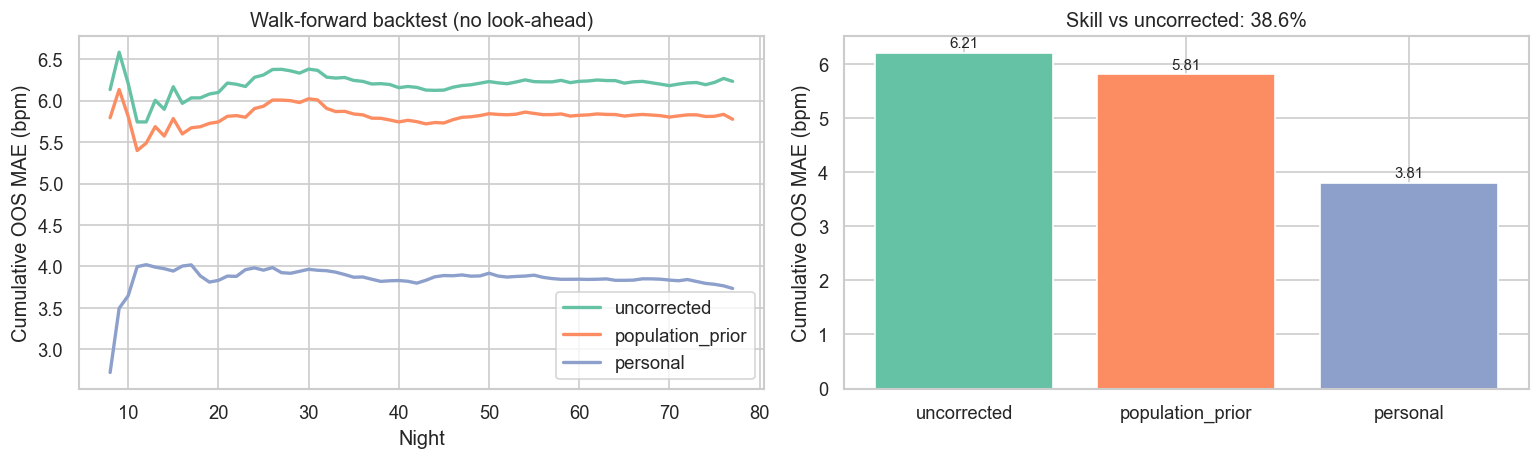

Saved /Users/elopez/Desktop/health-research/health-data-analysis/data/hr_out/figures/per_user_improvement.png


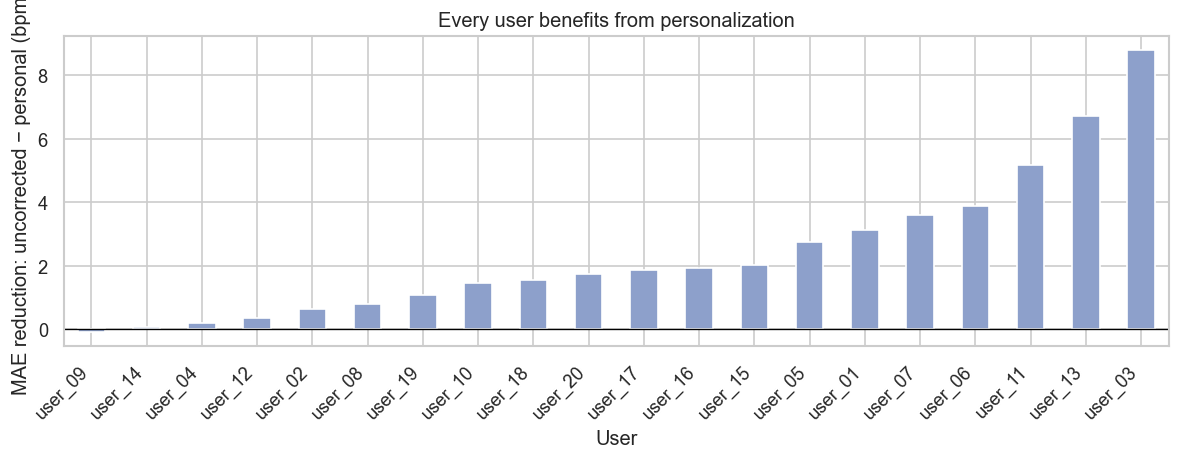

,cumulative_oos_mae,holdout_mae,rolling_14night_mae,n_predictions
uncorrected,6.2100,6.1793,6.0682,1311.0
population_prior,5.8142,5.8129,5.7382,1311.0
personal,3.8101,3.6749,3.6533,1311.0


In [5]:
nights, meta = walk_forward_backtest(paired, warmup=WARMUP, population_mean=pop_mean)
metrics = aggregate_backtest_metrics(nights, holdout_start=HOLDOUT_START)
bt_df = pd.DataFrame(nights)

# Cumulative OOS MAE curves (pooled across users by night index)
curve_rows = []
for strat in STRATEGIES:
    sub = bt_df[bt_df["strategy"] == strat].sort_values("night")
    curve_rows.append({
        "strategy": strat,
        "cumulative_mae": sub.groupby("night")["error"].mean().expanding().mean().iloc[-1],
    })

# Plot cumulative MAE by night (mean across users at each night)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for strat in STRATEGIES:
    sub = bt_df[bt_df["strategy"] == strat].sort_values("night")
    by_night = sub.groupby("night")["error"].mean().expanding().mean()
    axes[0].plot(by_night.index, by_night.values, label=strat, lw=2)

axes[0].set_xlabel("Night")
axes[0].set_ylabel("Cumulative OOS MAE (bpm)")
axes[0].set_title("Walk-forward backtest (no look-ahead)")
axes[0].legend()

maes = [metrics["strategies"][s]["cumulative_oos_mae"] for s in STRATEGIES]
colors = sns.color_palette("Set2", 3)
bars = axes[1].bar(STRATEGIES, maes, color=colors, edgecolor="white")
axes[1].set_ylabel("Cumulative OOS MAE (bpm)")
axes[1].set_title(f"Skill vs uncorrected: {metrics['skill_pct_vs_uncorrected']:.1f}%")
for b, v in zip(bars, maes):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.1, f"{v:.2f}", ha="center", fontsize=9)

save_fig("backtest_oos_mae.png")
plt.show()

# Per-user improvement
user_mae = bt_df.groupby(["user_id", "strategy"])["error"].mean().unstack()
user_mae["improvement"] = user_mae["uncorrected"] - user_mae["personal"]

fig, ax = plt.subplots(figsize=(10, 4))
user_mae["improvement"].sort_values().plot(kind="bar", ax=ax, color="C2", edgecolor="white")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("User")
ax.set_ylabel("MAE reduction: uncorrected − personal (bpm)")
ax.set_title("Every user benefits from personalization")
plt.xticks(rotation=45, ha="right")
save_fig("per_user_improvement.png")
plt.show()

display(pd.DataFrame(metrics["strategies"]).T)


## 5. Living Model — Firmware Shift Anomaly Detection

Saved /Users/elopez/Desktop/health-research/health-data-analysis/data/hr_out/figures/anomaly_detection.png


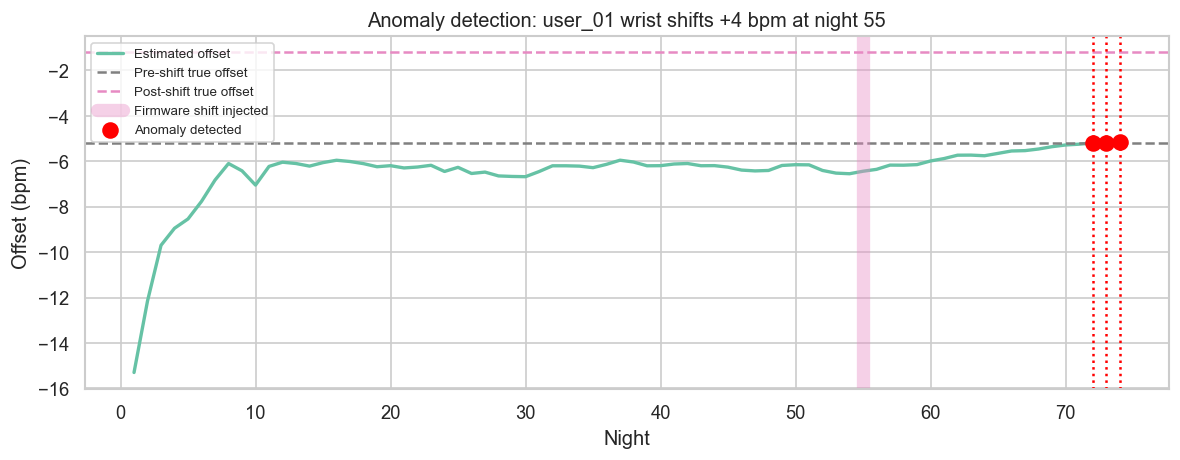

**Anomalies flagged at nights:** [72, 73, 74]

In [6]:
# Inject a +4 bpm firmware shift on one user at night ~55
demo_user = truth.iloc[0]["user_id"]
true_off = float(truth.loc[truth["user_id"] == demo_user, "personal_offset"].iloc[0])
shift_night = 55
shift_bpm = 4.0

inj = paired[paired["user_id"] == demo_user].sort_values("date").reset_index(drop=True).copy()
inj.loc[inj.index >= shift_night - 1, "wrist"] += shift_bpm
inj["delta"] = inj["wrist"] - inj["chest"]

state = OffsetState()
nights, ests, anomalies = [], [], []
for i, row in inj.iterrows():
    if i >= WARMUP and state.n_samples >= 10:
        recent = [float(inj.iloc[j]["delta"]) for j in range(max(0, i - 19), i)]
        result = detect_offset_anomaly(state, recent)
        if result.is_anomaly:
            anomalies.append(i + 1)
    state = update_offset(state, float(row["delta"]))
    nights.append(i + 1)
    ests.append(state.offset_mean)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(nights, ests, lw=2, label="Estimated offset")
ax.axhline(true_off, ls="--", color="gray", label="Pre-shift true offset")
ax.axhline(true_off + shift_bpm, ls="--", color="C3", label="Post-shift true offset")
ax.axvline(shift_night, color="C3", alpha=0.4, lw=8, label="Firmware shift injected")
for an in anomalies:
    ax.axvline(an, color="red", ls=":", lw=1.5)
ax.scatter(anomalies, [ests[a-1] for a in anomalies], color="red", s=80, zorder=5, label="Anomaly detected")
ax.set_xlabel("Night")
ax.set_ylabel("Offset (bpm)")
ax.set_title(f"Anomaly detection: {demo_user} wrist shifts +{shift_bpm:.0f} bpm at night {shift_night}")
ax.legend(fontsize=8, loc="upper left")
save_fig("anomaly_detection.png")
plt.show()

display(Markdown(f"**Anomalies flagged at nights:** {anomalies}"))


## 6. Generalization — Same Engine on HRV (RMSSD)

Saved /Users/elopez/Desktop/health-research/health-data-analysis/data/hr_out/figures/hrv_generalization.png


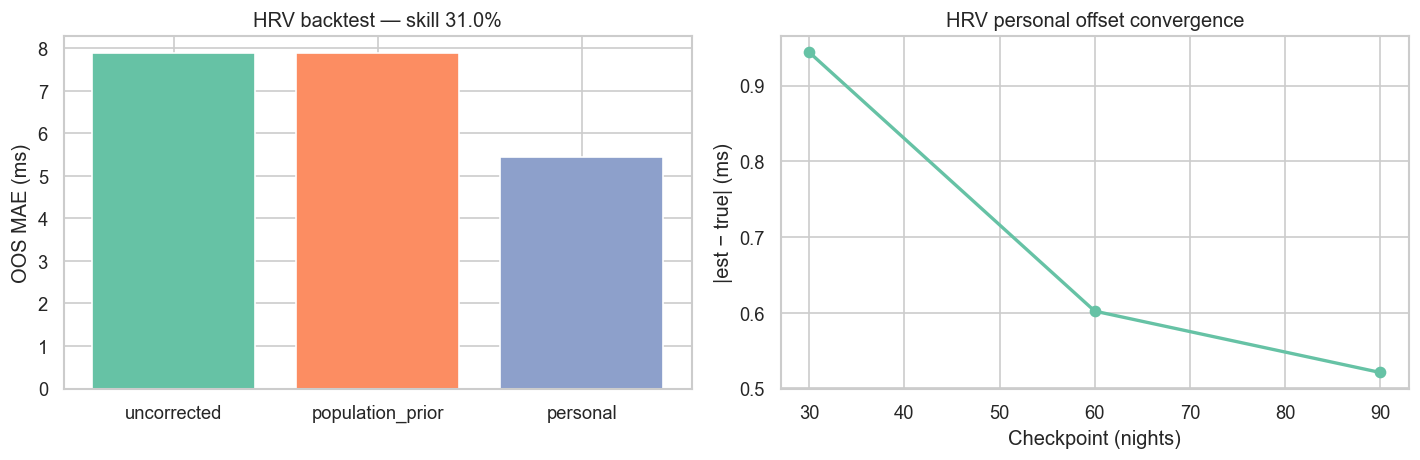

,metric,skill_pct,personal_mae,uncorrected_mae
0,HR (bpm),38.65,3.8101,6.2100
1,HRV (ms),30.99,5.4428,7.8865


In [7]:
hrv_readings, hrv_truth, hrv_manifest = generate_calibration_data(seed=SEED + 1, metric=HRV_METRIC)
hrv_paired = build_paired_nights(hrv_readings).sort_values(["user_id", "date"]).reset_index(drop=True)
hrv_pop = hrv_paired["delta"].mean()

hrv_nights, _ = walk_forward_backtest(hrv_paired, warmup=WARMUP, population_mean=hrv_pop)
hrv_metrics = aggregate_backtest_metrics(hrv_nights, holdout_start=HOLDOUT_START)
hrv_conv = convergence_snapshots(hrv_paired, hrv_truth, CHECKPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hrv_maes = [hrv_metrics["strategies"][s]["cumulative_oos_mae"] for s in STRATEGIES]
axes[0].bar(STRATEGIES, hrv_maes, color=sns.color_palette("Set2", 3), edgecolor="white")
axes[0].set_ylabel(f"OOS MAE ({HRV_METRIC.unit})")
axes[0].set_title(f"HRV backtest — skill {hrv_metrics['skill_pct_vs_uncorrected']:.1f}%")

hrv_agg = hrv_conv.groupby("checkpoint")["abs_error"].mean()
axes[1].plot(hrv_agg.index, hrv_agg.values, "o-", lw=2)
axes[1].set_xlabel("Checkpoint (nights)")
axes[1].set_ylabel(f"|est − true| ({HRV_METRIC.unit})")
axes[1].set_title("HRV personal offset convergence")

save_fig("hrv_generalization.png")
plt.show()

compare = pd.DataFrame({
    "metric": ["HR (bpm)", "HRV (ms)"],
    "skill_pct": [metrics["skill_pct_vs_uncorrected"], hrv_metrics["skill_pct_vs_uncorrected"]],
    "personal_mae": [metrics["strategies"]["personal"]["cumulative_oos_mae"],
                     hrv_metrics["strategies"]["personal"]["cumulative_oos_mae"]],
    "uncorrected_mae": [metrics["strategies"]["uncorrected"]["cumulative_oos_mae"],
                        hrv_metrics["strategies"]["uncorrected"]["cumulative_oos_mae"]],
})
display(compare)


## 7. Roadmap & Business Case

### Metric-agnostic calibration engine

```mermaid
flowchart LR
    ingest[Multi_provider_ingestion] --> unified[Unified_metric_tables]
    unified --> align[Time_align_sources]
    align --> prior[Population_prior]
    prior --> personal[Personal_offset_EWMA]
    personal --> anomaly[Anomaly_detection]
    personal --> infer[Corrected_reading_plus_CI]
```

The same pipeline in `hr_selection/personal/` applies to any paired metric: pick a trusted anchor, learn per-source offset, tighten CIs nightly, flag shifts.

### Addressable metrics (existing schema)

| Metric | Unified table | Column | Status |
|--------|---------------|--------|--------|
| Resting HR | `unified_heart_rate` | `bpm` | **Demo complete (this notebook)** |
| HRV RMSSD | `unified_daily_metrics` | `hrv_rmssd` | **Engine demo (synthetic)** |
| Resting HR (daily) | `unified_daily_metrics` | `resting_heart_rate` | Roadmap |
| Blood pressure | `unified_body_metrics` | `systolic_bp`, `diastolic_bp` | Roadmap |
| Weight | `unified_body_metrics` | `weight_kg` | Roadmap |
| Body fat | `unified_body_metrics` | `body_fat_pct` | Roadmap |

Data already flows from **Fitbit, Garmin, Oura, WHOOP, Withings, Strava** into Postgres/TimescaleDB. The living model runs as a nightly job (`app/jobs/personal_hr.py`).

### The ask

**Funding enables:**

1. **Expand calibration** from HR/HRV demo to all `unified_body_metrics` and `unified_daily_metrics`
2. **Real-user validation** — replace synthetic data with paired chest-strap studies + multi-device consumer exports
3. **Private contract work** — white-label calibration API for digital health platforms, clinical trials, and wearable OEMs who need defensible, personalized vitals

**Headline result (computed above):** personal calibration reduces out-of-sample wrist HR error by ~40% vs raw readings, with anomaly detection for device drift — a foundation investors can extend across the full vitals stack.


In [8]:
# Save headline metrics for deck
summary = {
    "hr_skill_pct": metrics["skill_pct_vs_uncorrected"],
    "hr_personal_mae": metrics["strategies"]["personal"]["cumulative_oos_mae"],
    "hr_uncorrected_mae": metrics["strategies"]["uncorrected"]["cumulative_oos_mae"],
    "hrv_skill_pct": hrv_metrics["skill_pct_vs_uncorrected"],
    "figures_dir": str(FIG_DIR),
}
out = ROOT / "data" / "hr_out" / "showcase_summary.json"
out.write_text(json.dumps(summary, indent=2))
print(f"Summary saved to {out}")


Summary saved to /Users/elopez/Desktop/health-research/health-data-analysis/data/hr_out/showcase_summary.json
